In [1]:
import os
import cv2
import numpy as np
from ultralytics import YOLO
from pathlib import Path
import shutil

In [2]:
PROCESSED_DIR = "../data/processed"  # Input: ảnh đã resize 224x224
CROPPED_DIR = "../data/cropped"      # Output: ảnh đã crop lá
YOLO_MODEL = "yolov8n.pt"            # Pretrained YOLO

In [3]:
CLASS_MAPPING = {
    "Bacterial Leaf Blight": "bacterial_blight",
    "Barrow Brown Leaf Spot": "barrow_brown_leaf_spot",
    "Brown Spot": "brown_spot",
    "Healthy Rice Leaf": "healthy",
    "Leaf Blast": "leaf_blast",
    "Leaf Scald": "leaf_scald",
    "Leaf Smut": "leaf_smut",
    "Neck Blast": "neck_blast",
    "Rice Hispa": "rice_hispa",
    "Sheath Blight": "sheath_blight",
    "Tungro": "tungro"
}

In [4]:
print("Loading YOLO model...")
yolo = YOLO(YOLO_MODEL)
print("YOLO loaded")

Loading YOLO model...
YOLO loaded


In [5]:
os.makedirs(CROPPED_DIR, exist_ok=True)
for class_name in CLASS_MAPPING.values():
    os.makedirs(os.path.join(CROPPED_DIR, class_name), exist_ok=True)

print("Folders created")

Folders created


In [6]:
def crop_leaf_from_image(image_path, yolo_model):
    """
    Detect và crop lá từ ảnh
    Returns: cropped image hoặc None nếu không detect được
    """
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    # Run YOLO detection
    results = yolo_model(img, verbose=False)
    
    # Lấy bounding box tốt nhất
    best_box = None
    best_conf = 0
    
    for result in results:
        boxes = result.boxes
        for box in boxes:
            conf = float(box.conf[0])
            cls = int(box.cls[0])
            
            # YOLO COCO: class 58='potted plant', 59='plant'
            # Hoặc chấp nhận mọi object có confidence cao
            if conf > best_conf and conf > 0.25:  # Threshold
                best_conf = conf
                best_box = box.xyxy[0].cpu().numpy().astype(int)
    
    if best_box is None:
        # Không detect được → Dùng center crop
        h, w = img.shape[:2]
        margin = int(min(h, w) * 0.1)  # Crop 80% center
        x1, y1 = margin, margin
        x2, y2 = w - margin, h - margin
        cropped = img[y1:y2, x1:x2]
        return cropped, "center_crop", 0.0
    
    # Crop theo bounding box
    x1, y1, x2, y2 = best_box
    
    # Thêm padding 5%
    h, w = img.shape[:2]
    pad = int(min(x2-x1, y2-y1) * 0.05)
    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(w, x2 + pad)
    y2 = min(h, y2 + pad)
    
    cropped = img[y1:y2, x1:x2]
    return cropped, "yolo_crop", best_conf

In [7]:
total_processed = 0
yolo_success = 0
center_crop_fallback = 0
failed = 0

for class_name in CLASS_MAPPING.values():
    print(f"\n Processing {class_name}...")
    
    src_dir = os.path.join(PROCESSED_DIR, class_name)
    dst_dir = os.path.join(CROPPED_DIR, class_name)
    
    images = os.listdir(src_dir)
    class_count = 0
    
    for img_name in images:
        src_path = os.path.join(src_dir, img_name)
        
        # Crop leaf
        result = crop_leaf_from_image(src_path, yolo)
        
        if result is None:
            failed += 1
            continue
        
        cropped_img, method, conf = result
        
        # Resize về 224x224
        cropped_resized = cv2.resize(cropped_img, (224, 224))
        
        # Save
        dst_path = os.path.join(dst_dir, img_name)
        cv2.imwrite(dst_path, cropped_resized)
        
        total_processed += 1
        class_count += 1
        
        if method == "yolo_crop":
            yolo_success += 1
        else:
            center_crop_fallback += 1
    
    print(f"   ✅ {class_name}: {class_count} ảnh")


 Processing bacterial_blight...
   ✅ bacterial_blight: 3637 ảnh

 Processing barrow_brown_leaf_spot...
   ✅ barrow_brown_leaf_spot: 1071 ảnh

 Processing brown_spot...
   ✅ brown_spot: 4712 ảnh

 Processing healthy...
   ✅ healthy: 3383 ảnh

 Processing leaf_blast...
   ✅ leaf_blast: 5104 ảnh

 Processing leaf_scald...
   ✅ leaf_scald: 2149 ảnh

 Processing leaf_smut...
   ✅ leaf_smut: 40 ảnh

 Processing neck_blast...
   ✅ neck_blast: 1000 ảnh

 Processing rice_hispa...
   ✅ rice_hispa: 1514 ảnh

 Processing sheath_blight...
   ✅ sheath_blight: 2532 ảnh

 Processing tungro...
   ✅ tungro: 1308 ảnh


In [8]:
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Total processed:       {total_processed:,}")
print(f"YOLO detected:         {yolo_success:,} ({yolo_success/total_processed*100:.1f}%)")
print(f"Center crop fallback:  {center_crop_fallback:,} ({center_crop_fallback/total_processed*100:.1f}%)")
print(f"Failed:                {failed}")
print("="*60)


SUMMARY
Total processed:       26,450
YOLO detected:         3,371 (12.7%)
Center crop fallback:  23,079 (87.3%)
Failed:                0


In [9]:
import matplotlib.pyplot as plt
import random

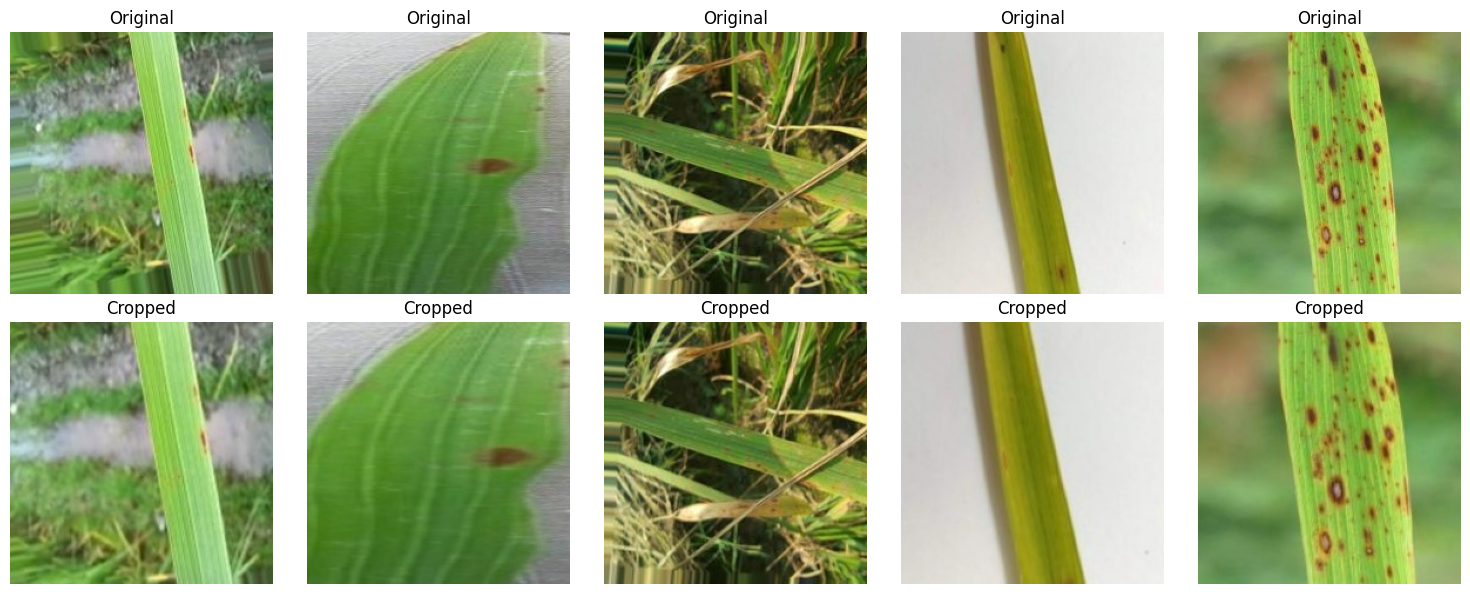

✅ Comparison saved to ../models/crop_comparison.png


In [11]:
# So sánh: Original vs Cropped
class_to_check = "brown_spot"
original_dir = os.path.join(PROCESSED_DIR, class_to_check)
cropped_dir = os.path.join(CROPPED_DIR, class_to_check)

sample_images = random.sample(os.listdir(cropped_dir), 5)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, img_name in enumerate(sample_images):
    # Original
    orig = cv2.imread(os.path.join(original_dir, img_name))
    orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(orig_rgb)
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')
    
    # Cropped
    crop = cv2.imread(os.path.join(cropped_dir, img_name))
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(crop_rgb)
    axes[1, i].set_title("Cropped")
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig("../models/crop_comparison.png")
plt.show()

print("✅ Comparison saved to ../models/crop_comparison.png")